In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.cluster import KMeans

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("Mall_Customers.csv")

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
print("Shape:", df.shape)

df.info()

df.describe()

Shape: (200, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


Check Missing Values

In [4]:
df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


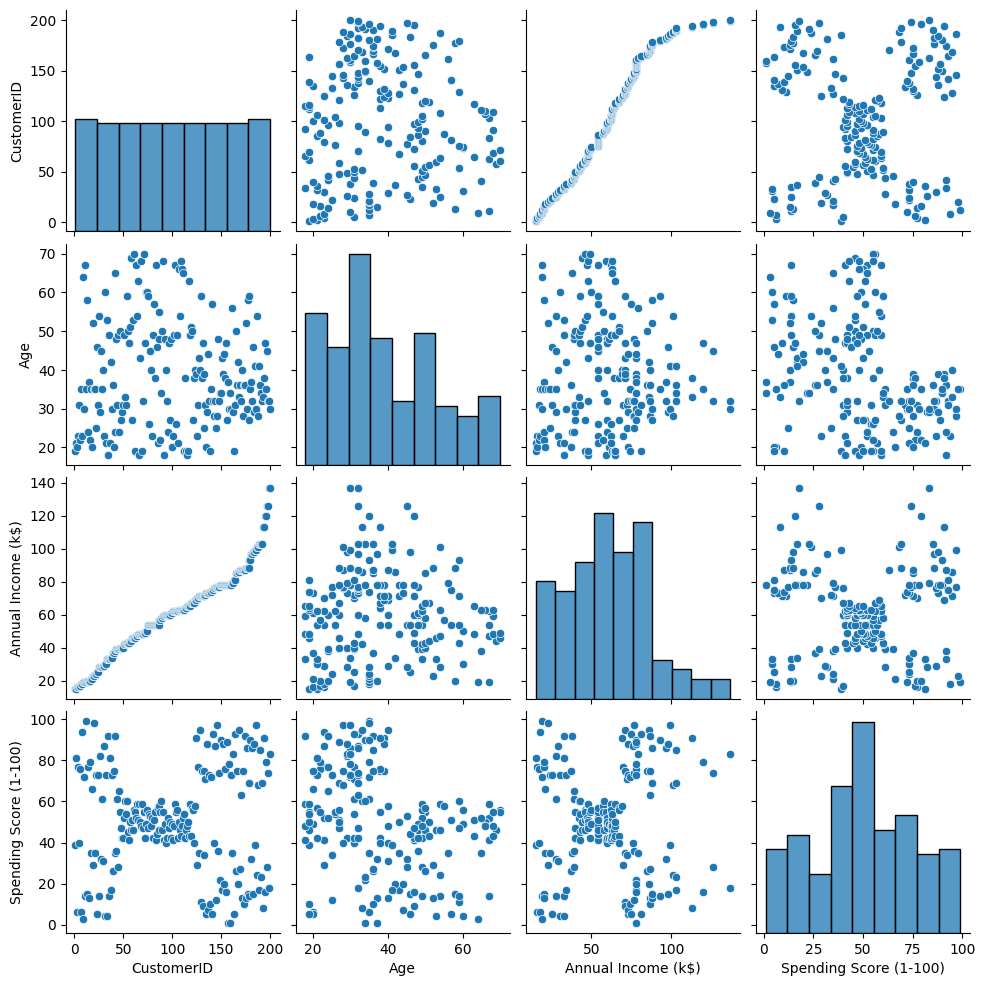

In [5]:
sns.pairplot(df)
plt.show()

Feature Selection

Using:

Annual Income
,Spending Score

In [6]:
X = df.iloc[:, [3,4]].values

X[:5]

array([[15, 39],
       [15, 81],
       [16,  6],
       [16, 77],
       [17, 40]])

Elbow Method

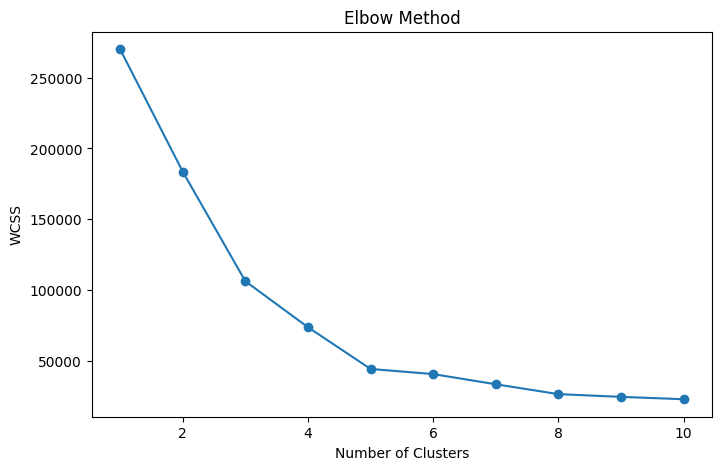

In [7]:
wcss = []

for i in range(1,11):

    kmeans = KMeans(
        n_clusters=i,
        init='k-means++',
        random_state=42
    )

    kmeans.fit(X)

    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker='o'
)

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

plt.savefig("elbow_method.png")

plt.show()

Train K-Means Model

In [8]:
kmeans = KMeans(
    n_clusters=5,
    init='k-means++',
    random_state=42
)

y_kmeans = kmeans.fit_predict(X)

Cluster Visualization

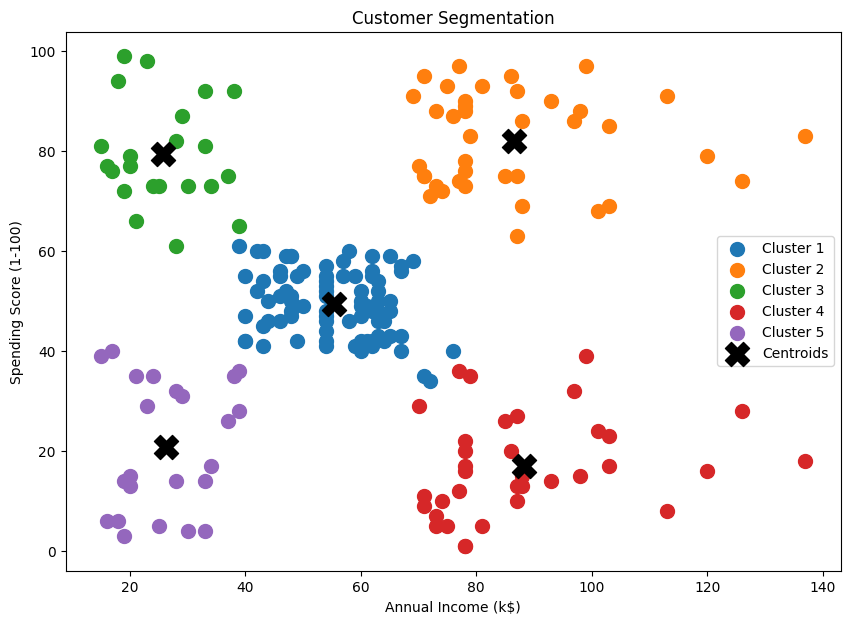

In [9]:
plt.figure(figsize=(10,7))

plt.scatter(
    X[y_kmeans == 0,0],
    X[y_kmeans == 0,1],
    s=100,
    label='Cluster 1'
)

plt.scatter(
    X[y_kmeans == 1,0],
    X[y_kmeans == 1,1],
    s=100,
    label='Cluster 2'
)

plt.scatter(
    X[y_kmeans == 2,0],
    X[y_kmeans == 2,1],
    s=100,
    label='Cluster 3'
)

plt.scatter(
    X[y_kmeans == 3,0],
    X[y_kmeans == 3,1],
    s=100,
    label='Cluster 4'
)

plt.scatter(
    X[y_kmeans == 4,0],
    X[y_kmeans == 4,1],
    s=100,
    label='Cluster 5'
)

plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    s=300,
    c='black',
    marker='X',
    label='Centroids'
)

plt.title('Customer Segmentation')

plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')

plt.legend()

plt.savefig("customer_clusters.png")

plt.show()

Add Cluster Labels

In [10]:
df["Cluster"] = y_kmeans

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


In [11]:
df.to_csv(
    "clustered_customers.csv",
    index=False
)

print("Clustered dataset saved.")

Clustered dataset saved.


In [12]:
joblib.dump(
    kmeans,
    "kmeans_model.pkl"
)

print("Model saved successfully.")

Model saved successfully.


In [13]:
from google.colab import files

files.download("clustered_customers.csv")
files.download("kmeans_model.pkl")
files.download("elbow_method.png")
files.download("customer_clusters.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>